# Dynamic Programming: Policy Iteration vs. Truncated Policy Iteration

This notebook compares standard policy iteration with a truncated version that limits the amount of policy evaluation per outer loop. The goal is to examine how a smaller evaluation budget affects convergence speed and the final solution.

In [1]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np

sys.path.append(os.path.abspath(".."))

from envs.grid_world import GridWorld
from algorithms.policy_iteration import policy_iteration
from algorithms.value_iteration import value_iteration
from utils import (
    plot_value_grid,
    plot_policy_arrows,
    plot_value_and_policy,
    plot_convergence_comparison,
)

%matplotlib inline

## Environment Setup

We use a deterministic GridWorld with reproducible terminal states so both algorithms are evaluated on exactly the same MDP instance.

In [4]:
env = GridWorld(n_rows=9, n_cols=16, seed=782026)

gamma = 0.95
seed = 1024

print("Environment Configuration:")
print(f"  - Total Grid States: {len(env.states)}")
print(f"  - Terminal States: {env.terminal_states}")
print(f"  - Non-Terminal States: {len(env.non_terminal_states)}")
print(f"  - Available Actions: {env.ACTIONS}")

Environment Configuration:
  - Total Grid States: 144
  - Terminal States: [(1, 13), (5, 14)]
  - Non-Terminal States: 142
  - Available Actions: ['up', 'down', 'left', 'right']


## Policy Iteration Run

We run standard policy iteration and truncated policy iteration with the same discount factor and random seed. The printed outputs and plots below show how the truncated evaluation schedule changes the convergence path.

Policy Iteration completed in 44730 Bellman backups.
Truncated Policy Iteration completed in 14626 Bellman backups.
Do optimal values match? True
Do optimal policies match? True


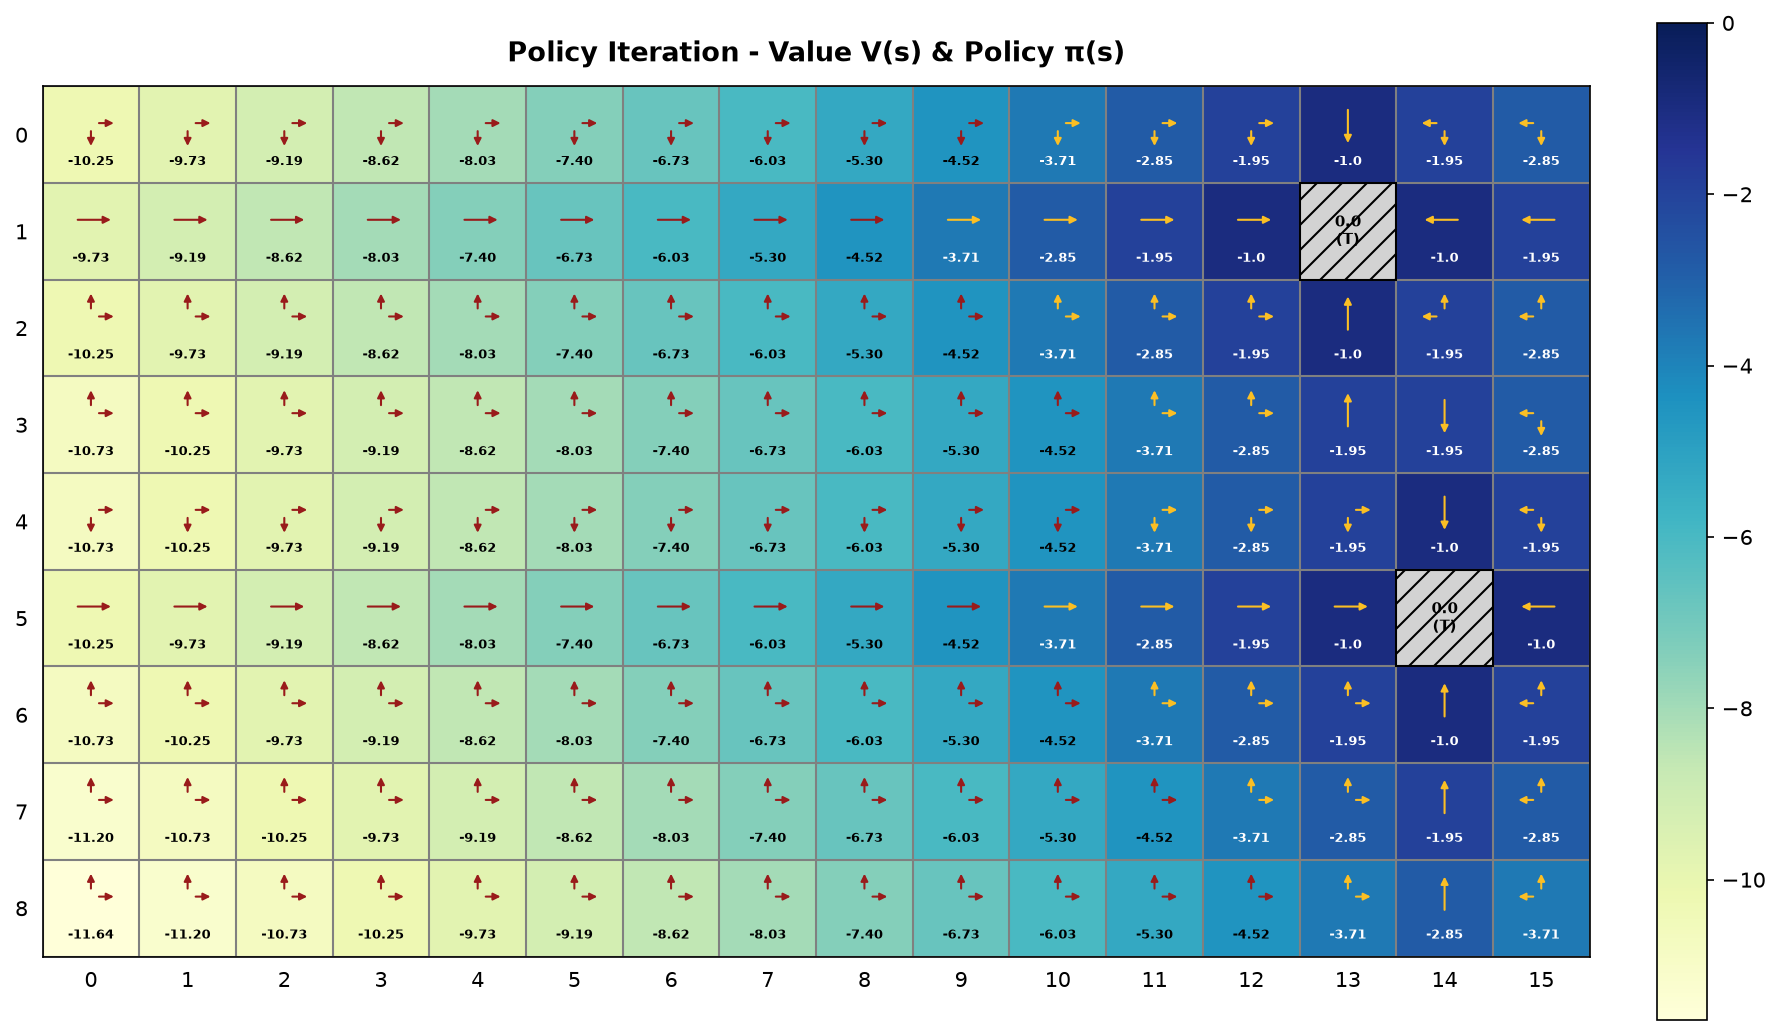

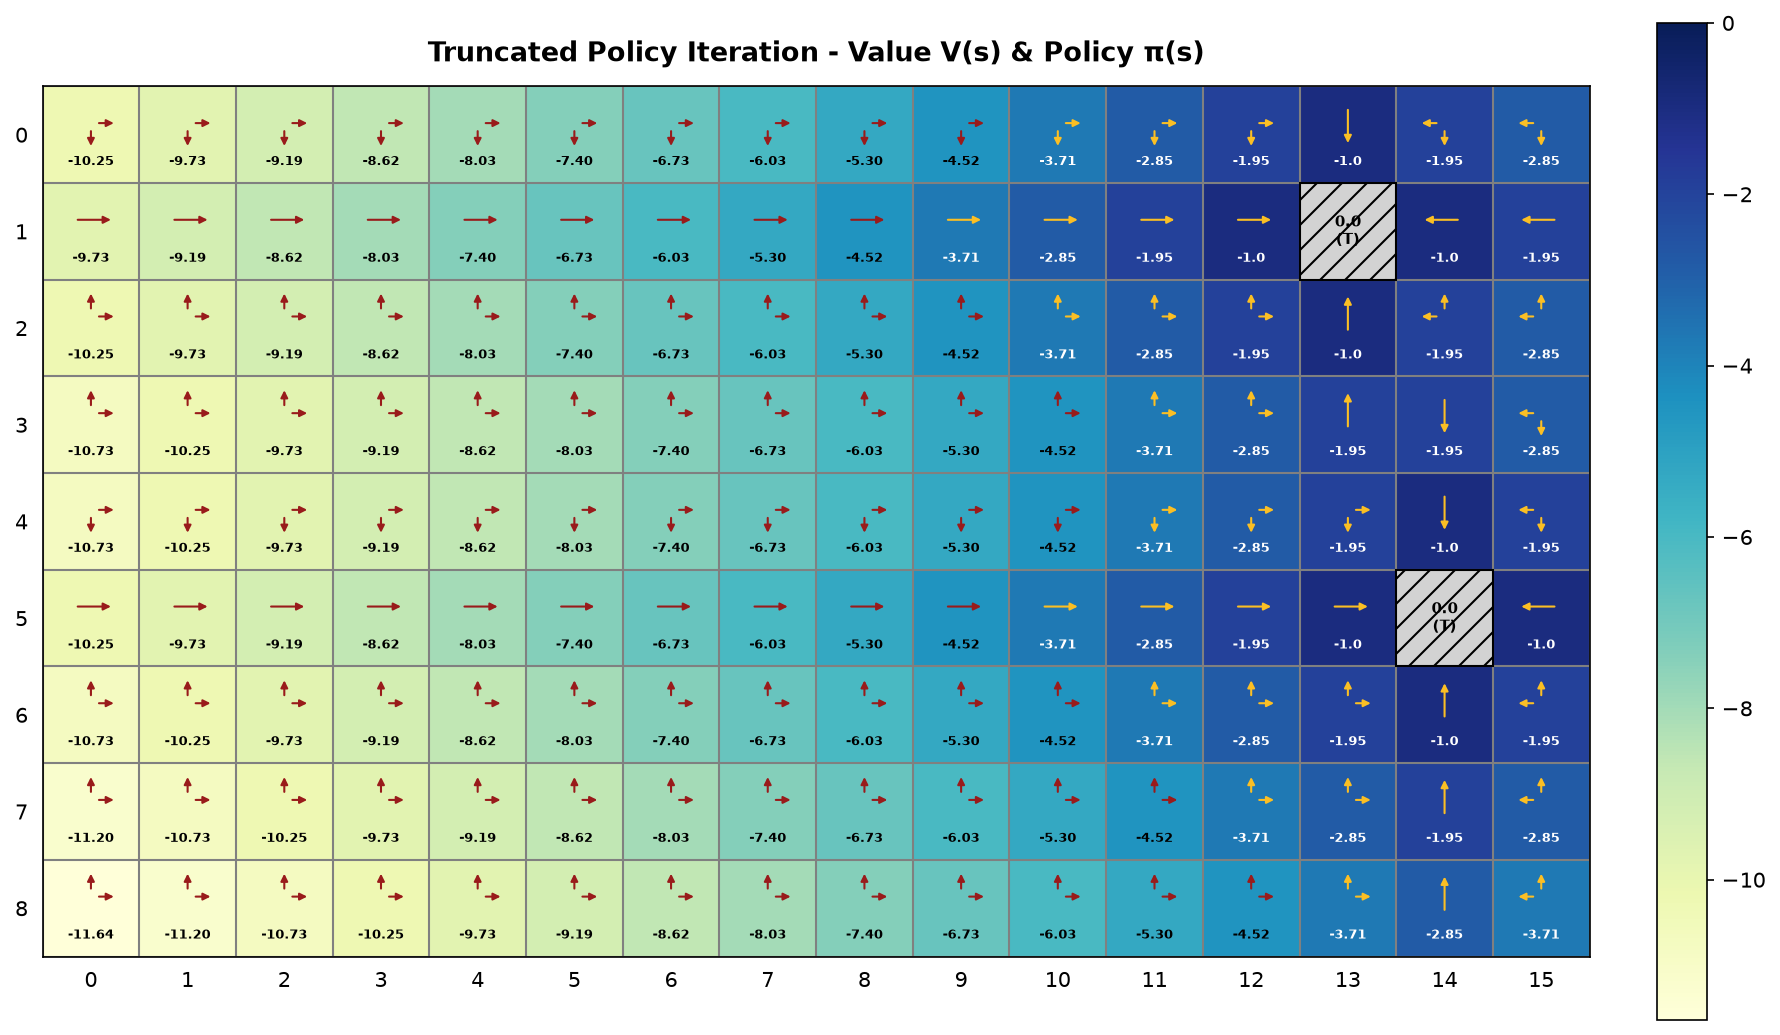

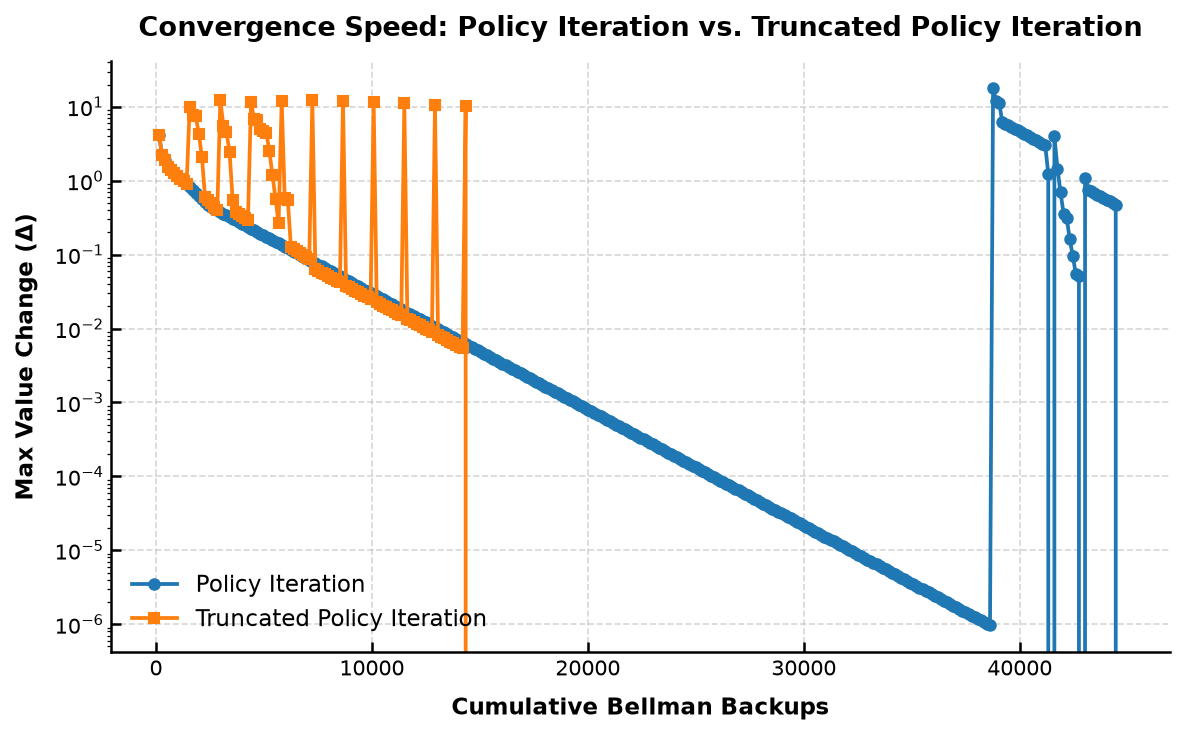

In [6]:
V_pi, pi_pi, history_pi = policy_iteration(
    env=env,
    gamma=gamma,
    seed=seed,
)

V_truncated_pi, pi_truncated_pi, history_truncated_pi = policy_iteration(
    env=env,
    gamma=gamma,
    seed=seed,
    truncated_steps=10
)

print(f"Policy Iteration completed in {history_pi['backup_count'][-1]} Bellman backups.")
print(f"Truncated Policy Iteration completed in {history_truncated_pi['backup_count'][-1]} Bellman backups.")
print(f"Do optimal values match? {np.allclose(V_pi, V_truncated_pi, atol=1e-5)}")
print(f"Do optimal policies match? {pi_pi == pi_truncated_pi}")

fig1, ax1 = plot_value_and_policy(
    env,
    V_pi,
    pi_pi,
    title="Policy Iteration - Value V(s) & Policy π(s)",
)
plt.show()

fig2, ax2 = plot_value_and_policy(
    env,
    V_truncated_pi,
    pi_truncated_pi,
    title="Truncated Policy Iteration - Value V(s) & Policy π(s)",
)
plt.show()

comparison_history = {
    "Policy Iteration": history_pi,
    "Truncated Policy Iteration": history_truncated_pi,
}

fig3, ax3 = plot_convergence_comparison(
    comparison_history,
    log_scale=True,
    title="Convergence Speed: Policy Iteration vs. Truncated Policy Iteration",
)
plt.show()

## Remarks

Truncated policy iteration reaches the same optimal value function and policy as standard policy iteration in this experiment, which confirms that the truncated evaluation budget is still sufficient to recover the optimal solution. The main difference is in the convergence trace: the truncated version shows repeated spikes because each outer loop uses only a partial evaluation step, but it still finishes with far fewer Bellman backups overall. In this run, truncated policy iteration completed in 14,626 backups versus 44,730 for full policy iteration, so it is noticeably more efficient while preserving the final result.